# 04. Anomaly Detection & Time Series Forecasting

**Objectives:**
- Detect anomalous days in power consumption
- Analyze anomalies by season
- Build forecasting models (ARIMA, ETS, Holt-Winters)
- Compare model performance
- Analyze forecast residuals

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import PowerDataLoader
from src.mining.anomaly import PowerAnomalyDetector
from src.models.forecasting import PowerForecaster
from src.evaluation.metrics import ForecastingMetrics, ResidualAnalyzer
from src.visualization.plots import PowerVisualizer
from src.evaluation.report import ReportGenerator

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## PART 1: ANOMALY DETECTION

### 1.1 Load Data

In [2]:
# Load cleaned data
loader = PowerDataLoader(config_path='../configs/params.yaml')
df_clean = loader.load_processed_data('cleaned_data.parquet')

print(f"Data loaded: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")

Loaded processed data from data\processed\cleaned_data.parquet
Data loaded: (34589, 8)
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


### 1.2 Prepare Daily Features

In [3]:
# Initialize anomaly detector
detector = PowerAnomalyDetector(config_path='../configs/params.yaml')

# Prepare daily features
df_daily = detector.prepare_daily_features(df_clean)

print(f"\nDaily features shape: {df_daily.shape}")
print(f"\nFeatures:")
print(df_daily.columns.tolist())
df_daily.head()

Preparing daily features for anomaly detection...
Created daily features: 1442 days, 11 features

Daily features shape: (1442, 11)

Features:
['Global_active_power_mean', 'Global_active_power_std', 'Global_active_power_min', 'Global_active_power_max', 'Global_active_power_sum', 'range', 'cv', 'day_of_week', 'month', 'is_weekend', 'season']


,Global_active_power_mean,Global_active_power_std,Global_active_power_min,Global_active_power_max,Global_active_power_sum,range,cv,day_of_week,month,is_weekend,season
datetime,,,,,,,,,,,
2006-12-16,3.120298,0.769168,2.061600,4.222889,21.842089,2.161289,0.246505,5,12,1,0
2006-12-17,2.354486,0.862821,0.437733,3.697100,56.507667,3.259367,0.366458,6,12,1,0
2006-12-18,1.530435,0.817779,0.276367,3.050567,36.730433,2.774200,0.534344,0,12,0,0
2006-12-19,1.157079,0.993433,0.300467,3.879033,27.769900,3.578567,0.858569,1,12,0,0
2006-12-20,1.545658,1.204481,0.258667,3.646067,37.095800,3.387400,0.779267,2,12,0,0


### 1.3 Detect Anomalies (Isolation Forest)

In [4]:
# Detect using Isolation Forest
anomaly_labels = detector.detect_anomalies_isolation_forest(
    df_daily,
    contamination=0.05
)

print(f"\nAnomalies detected: {anomaly_labels.sum()} days")
print(f"Anomaly rate: {anomaly_labels.sum()/len(df_daily)*100:.2f}%")


Detecting anomalies using Isolation Forest...
  Contamination: 0.05
  Features: ['Global_active_power_mean', 'Global_active_power_std', 'Global_active_power_min', 'Global_active_power_max', 'Global_active_power_sum', 'range', 'cv', 'day_of_week', 'month', 'is_weekend', 'season']
  Detected 73 anomalies (5.06%)

Anomalies detected: 73 days
Anomaly rate: 5.06%


### 1.4 Seasonal Analysis

In [5]:
# Analyze by season
seasonal_analysis = detector.analyze_by_season(
    df_daily,
    anomaly_labels
)

print("\nSeasonal Anomaly Analysis:")
print(seasonal_analysis)


SEASONAL ANOMALY ANALYSIS
             n_anomalies  anomaly_rate  total_days
season_name                                       
Winter                30      0.086705         346
Summer                29      0.078804         368
Spring                 8      0.021739         368
Autumn                 6      0.016667         360

Seasonal Anomaly Analysis:
             n_anomalies  anomaly_rate  total_days
season_name                                       
Winter                30      0.086705         346
Summer                29      0.078804         368
Spring                 8      0.021739         368
Autumn                 6      0.016667         360


### 1.5 Visualize Anomalies

Saved figure to outputs\figures\04_anomalies_detected.png


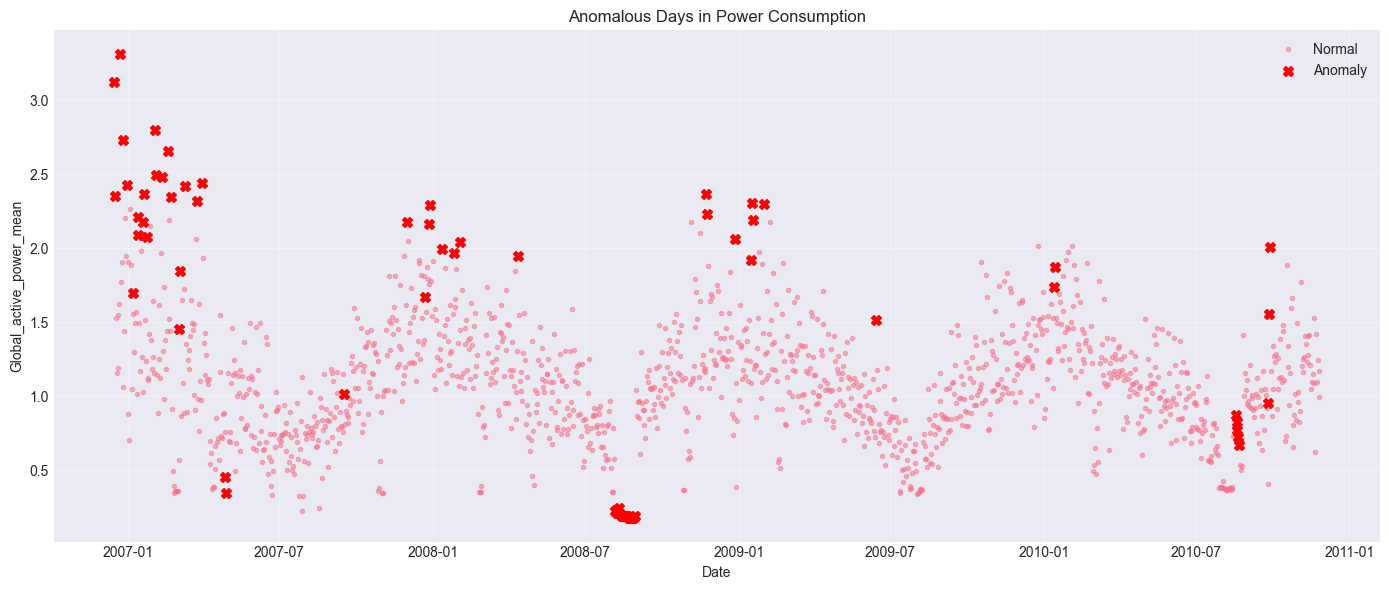

In [6]:
# Visualize anomalies
viz = PowerVisualizer(config_path='../configs/params.yaml')

viz.plot_anomalies(
    df_daily,
    anomaly_labels,
    column='Global_active_power_mean',
    title='Anomalous Days in Power Consumption',
    filename='04_anomalies_detected.png'
)
plt.show()

### 1.6 Get Anomaly Details

In [7]:
# Get top anomalies
top_anomalies = detector.get_anomaly_details(
    df_daily,
    anomaly_labels,
    n_top=10
)


TOP 10 ANOMALOUS DAYS
            Global_active_power_mean  Global_active_power_std  \
datetime                                                        
2006-12-23                  3.314851                 1.176855   
2006-12-16                  3.120298                 0.769168   
2007-02-03                  2.798418                 1.119352   
2006-12-26                  2.732021                 0.778898   
2007-02-18                  2.659557                 1.233371   
2007-02-04                  2.497181                 0.861033   
2007-02-11                  2.480019                 0.769911   
2007-03-31                  2.437160                 1.108525   
2006-12-31                  2.426525                 1.027505   
2007-03-11                  2.417108                 0.844028   

            Global_active_power_min  Global_active_power_max  \
datetime                                                       
2006-12-23                 1.649367                 5.562467   
2006

## PART 2: TIME SERIES FORECASTING

### 2.1 Prepare Data for Forecasting

In [8]:
# Use hourly data
df_hourly = df_clean.copy()

# Remove outliers for better forecasting
if 'is_outlier' in df_hourly.columns:
    df_hourly = df_hourly[~df_hourly['is_outlier']].copy()

print(f"Hourly data for forecasting: {df_hourly.shape}")

Hourly data for forecasting: (27924, 8)


### 2.2 Train-Test Split

In [9]:
# Initialize forecaster
forecaster = PowerForecaster(config_path='../configs/params.yaml')

# Split data (last 7 days for testing)
train, test, val = forecaster.train_test_split(
    df_hourly,
    target_col='Global_active_power',
    test_days=7,
    val_days=3
)

print(f"\nTrain size: {len(train)}")
print(f"Validation size: {len(val) if val is not None else 0}")
print(f"Test size: {len(test)}")

Data split:
  Train: 27914 samples (2006-12-16 17:00:00 to 2010-11-26 11:00:00)
  Validation: 3 samples (2010-11-26 12:00:00 to 2010-11-26 14:00:00)
  Test: 7 samples (2010-11-26 15:00:00 to 2010-11-26 21:00:00)

Train size: 27914
Validation size: 3
Test size: 7


### 2.3 Baseline Model (Seasonal Naive)

In [10]:
# Baseline
forecast_baseline = forecaster.baseline_seasonal_naive(
    train,
    test,
    seasonal_period=24
)

# Evaluate
metrics_baseline = ForecastingMetrics.calculate_all(test, forecast_baseline)
print("\nBaseline Metrics:")
for metric, value in metrics_baseline.items():
    print(f"  {metric.upper()}: {value:.4f}")


Training Seasonal Naive Baseline (period=24)...

Baseline Metrics:
  MAE: 0.7212
  RMSE: 0.8134
  MAPE: 53.5999
  SMAPE: 79.3010
  R2: -5.0201


### 2.4 ARIMA Model

In [11]:
# Fit ARIMA
print("Training ARIMA model... (this may take a while)")
arima_model = forecaster.fit_arima(
    train,
    auto=True  # Use auto_arima if available
)

# Forecast
forecast_arima = forecaster.forecast('arima', len(test))
forecast_arima.index = test.index

# Evaluate
metrics_arima = ForecastingMetrics.calculate_all(test, forecast_arima)
print("\nARIMA Metrics:")
for metric, value in metrics_arima.items():
    print(f"  {metric.upper()}: {value:.4f}")

Training ARIMA model... (this may take a while)

Training ARIMA model (auto=True)...
Fitting ARIMA(1, 1, 1)...

Generating 7-step forecast using arima...

ARIMA Metrics:
  MAE: 0.3579
  RMSE: 0.4485
  MAPE: 25.0159
  SMAPE: 28.5686
  R2: -0.8308


### 2.5 ETS (Exponential Smoothing)

In [12]:
# Fit ETS
print("Training ETS model...")
ets_model = forecaster.fit_ets(
    train,
    seasonal='add',
    seasonal_periods=24
)

# Forecast
forecast_ets = forecaster.forecast('ets', len(test))
forecast_ets.index = test.index

# Evaluate
metrics_ets = ForecastingMetrics.calculate_all(test, forecast_ets)
print("\nETS Metrics:")
for metric, value in metrics_ets.items():
    print(f"  {metric.upper()}: {value:.4f}")

Training ETS model...

Training ETS model (seasonal=add, periods=24)...

Generating 7-step forecast using ets...

ETS Metrics:
  MAE: 0.3203
  RMSE: 0.3342
  MAPE: 27.4526
  SMAPE: 25.0865
  R2: -0.0165


### 2.6 Holt-Winters Model

In [13]:
# Fit Holt-Winters
print("Training Holt-Winters model...")
hw_model = forecaster.fit_holt_winters(
    train,
    seasonal='add',
    seasonal_periods=24,
    trend='add'
)

# Forecast
forecast_hw = forecaster.forecast('holt_winters', len(test))
forecast_hw.index = test.index

# Evaluate
metrics_hw = ForecastingMetrics.calculate_all(test, forecast_hw)
print("\nHolt-Winters Metrics:")
for metric, value in metrics_hw.items():
    print(f"  {metric.upper()}: {value:.4f}")

Training Holt-Winters model...

Training Holt-Winters model...
  Trend: add, Seasonal: add, Periods: 24

Generating 7-step forecast using holt_winters...

Holt-Winters Metrics:
  MAE: 0.3203
  RMSE: 0.3342
  MAPE: 27.4526
  SMAPE: 25.0865
  R2: -0.0165


### 2.7 Compare All Models

In [14]:
# Compare models
predictions = {
    'Seasonal Naive': forecast_baseline,
    'ARIMA': forecast_arima,
    'ETS': forecast_ets,
    'Holt-Winters': forecast_hw
}

comparison = ForecastingMetrics.compare_models(
    test,
    predictions,
    metrics=['mae', 'rmse', 'smape']
)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison)
print("="*80)


MODEL COMPARISON
                     mae      rmse     smape  mae_rank  rmse_rank  smape_rank  \
Holt-Winters    0.320278  0.334217  25.08650       1.5        1.5         1.5   
ETS             0.320278  0.334217  25.08650       1.5        1.5         1.5   
ARIMA           0.357923  0.448534  28.56864       3.0        3.0         3.0   
Seasonal Naive  0.721229  0.813351  79.30097       4.0        4.0         4.0   

                avg_rank  
Holt-Winters         1.5  
ETS                  1.5  
ARIMA                3.0  
Seasonal Naive       4.0  


### 2.8 Visualize Forecasts

Saved figure to outputs\figures\04_forecast_comparison.png


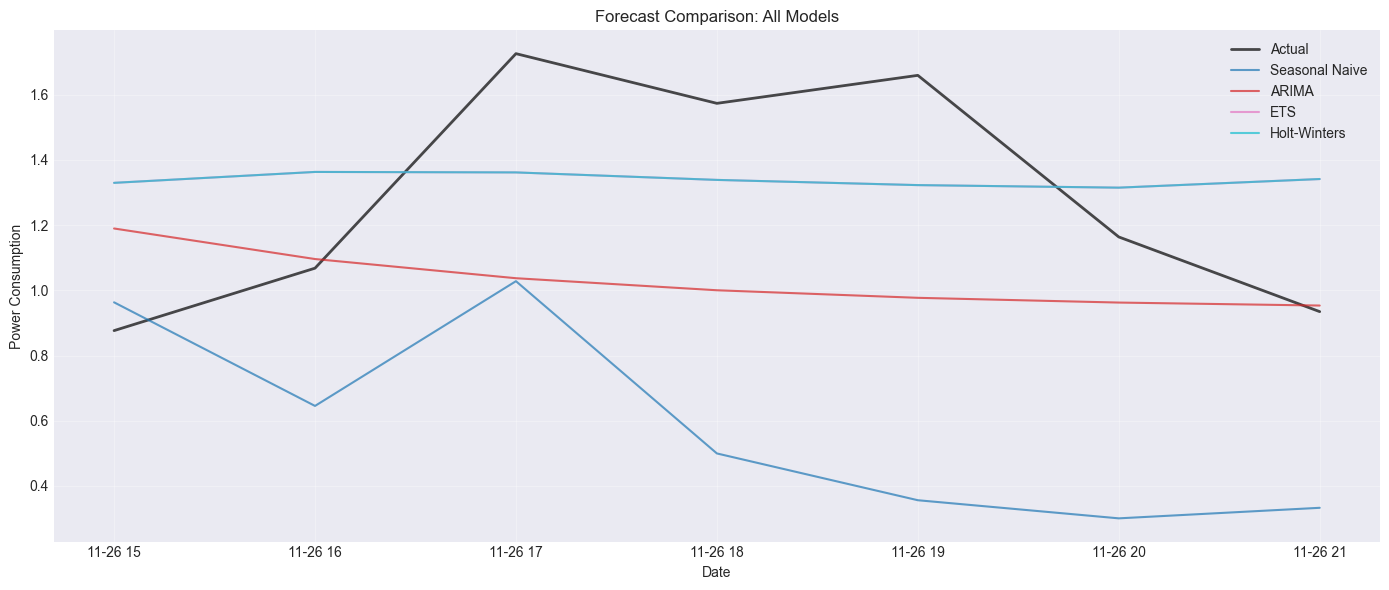

In [15]:
# Plot forecast comparison
viz.plot_forecast_comparison(
    test,
    predictions,
    title='Forecast Comparison: All Models',
    filename='04_forecast_comparison.png',
    max_points=200
)
plt.show()

Saved figure to outputs\figures\04_model_comparison_bar.png


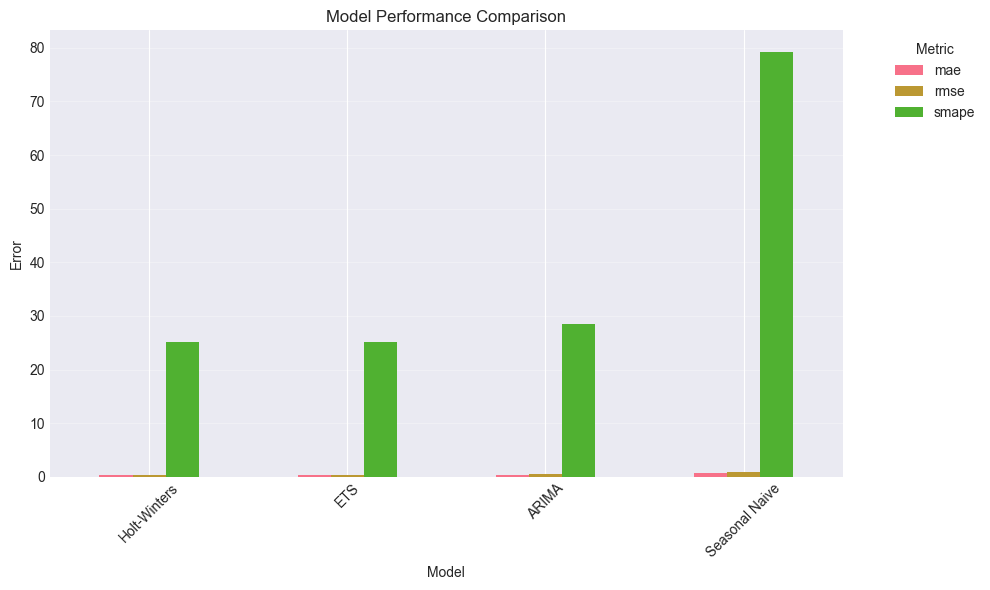

In [16]:
# Plot model comparison bar chart
viz.plot_model_comparison_bar(
    comparison,
    metrics=['mae', 'rmse', 'smape'],
    filename='04_model_comparison_bar.png'
)
plt.show()

### 2.9 Residual Analysis

In [17]:
# Analyze residuals for best model
best_model = comparison.index[0]
best_forecast = predictions[best_model]

print(f"Best model: {best_model}")

# Calculate residuals
residuals = ResidualAnalyzer.calculate_residuals(test, best_forecast)

# Analyze
residual_stats = ResidualAnalyzer.analyze_residuals(residuals)
print("\nResidual Statistics:")
for stat, value in residual_stats.items():
    print(f"  {stat}: {value:.4f}")

# Detect outliers in residuals
residual_outliers = ResidualAnalyzer.detect_residual_outliers(residuals, threshold=3.0)
print(f"\nResidual outliers: {residual_outliers.sum()}")

Best model: Holt-Winters

Residual Statistics:
  mean: -0.0529
  std: 0.3564
  min: -0.4532
  max: 0.3643
  q25: -0.3509
  q50: -0.1512
  q75: 0.2857
  skewness: 0.1649
  kurtosis: -2.3630

Residual outliers: 0


Saved figure to outputs\figures\04_residuals.png


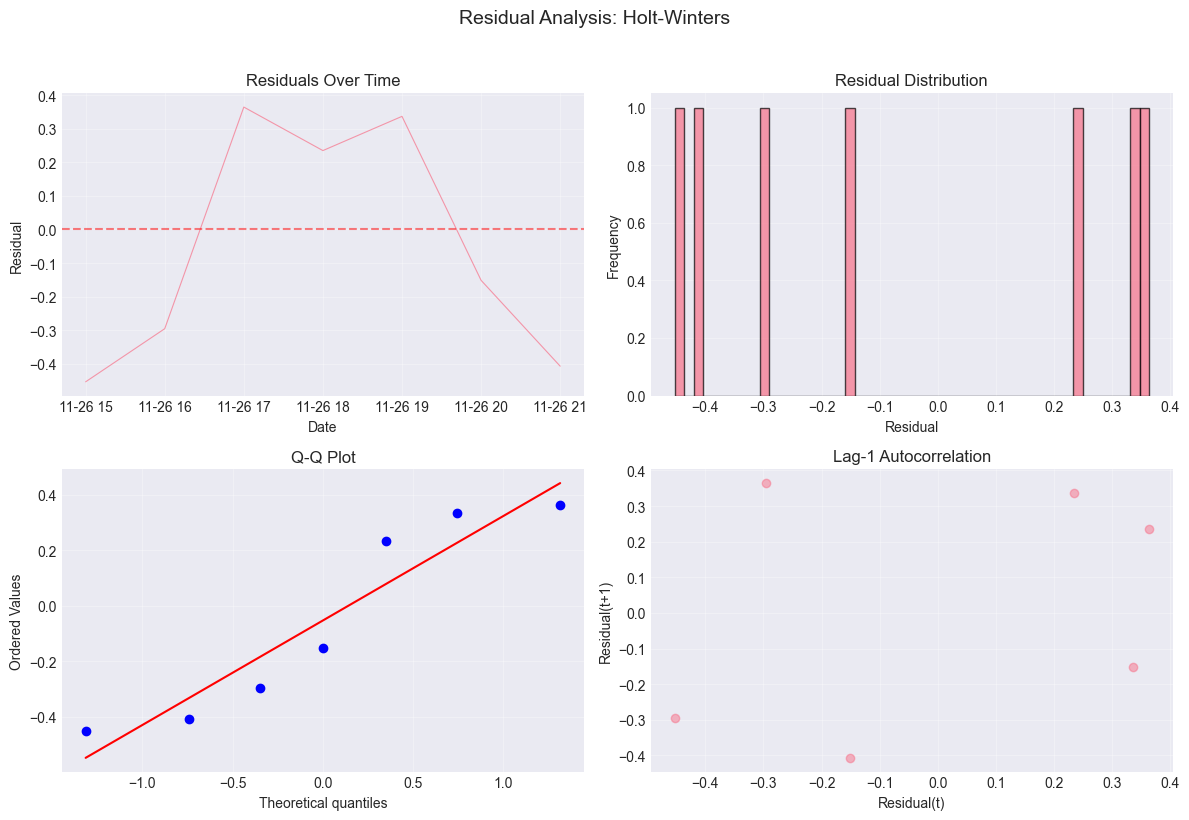

In [18]:
# Plot residual analysis
viz.plot_residuals(
    residuals,
    title=f'Residual Analysis: {best_model}',
    filename='04_residuals.png'
)
plt.show()

### 2.10 Seasonal Residual Analysis

In [19]:
# Analyze residuals by season
seasonal_residuals = ResidualAnalyzer.analyze_by_season(residuals)

print("\nResiduals by Season:")
print(seasonal_residuals)


Residuals by Season:
        count      mean       std       min       max
season                                               
Autumn      7 -0.052937  0.356439 -0.453204  0.364261


## 3. Save Results

In [20]:
# Save model comparison
reporter = ReportGenerator(config_path='../configs/params.yaml')
reporter.create_model_comparison_table(
    comparison,
    filename='forecast_model_comparison.csv'
)

# Save anomaly summary
reporter.create_anomaly_summary(
    top_anomalies,
    seasonal_analysis,
    filename='seasonal_anomaly_analysis.csv'
)

# Save forecast summary
residual_stats_all = {
    model_name: ResidualAnalyzer.analyze_residuals(
        ResidualAnalyzer.calculate_residuals(test, pred)
    )
    for model_name, pred in predictions.items()
}

reporter.create_forecast_summary(
    comparison,
    residual_stats_all,
    filename='forecast_summary.txt'
)

print("\nAll results saved successfully!")

Saved model comparison table to outputs\tables\forecast_model_comparison.csv

MODEL COMPARISON
                   mae    rmse    smape  mae_rank  rmse_rank  smape_rank  avg_rank
Holt-Winters    0.3203  0.3342  25.0865       1.5        1.5         1.5       1.5
ETS             0.3203  0.3342  25.0865       1.5        1.5         1.5       1.5
ARIMA           0.3579  0.4485  28.5686       3.0        3.0         3.0       3.0
Seasonal Naive  0.7212  0.8134  79.3010       4.0        4.0         4.0       4.0
Saved seasonal anomaly analysis to outputs\tables\seasonal_anomaly_analysis.csv

ANOMALY DETECTION SUMMARY
total_days: 1452
anomalous_days: 10
anomaly_rate: 0.6887
Saved forecast summary to outputs\tables\forecast_summary.txt

All results saved successfully!


## Summary

In [21]:
print("=" * 80)
print("ANOMALY DETECTION & FORECASTING SUMMARY")
print("=" * 80)

print("\n1. ANOMALY DETECTION:")
print(f"   - Method: Isolation Forest")
print(f"   - Total days: {len(df_daily)}")
print(f"   - Anomalous days: {anomaly_labels.sum()}")
print(f"   - Anomaly rate: {anomaly_labels.sum()/len(df_daily)*100:.2f}%")
print(f"   - Seasonal analysis: Complete")

print("\n2. FORECASTING:")
print(f"   - Models tested: {len(predictions)}")
print(f"   - Best model: {best_model}")
print(f"   - Best MAE: {comparison.loc[best_model, 'mae']:.4f}")
print(f"   - Best RMSE: {comparison.loc[best_model, 'rmse']:.4f}")
print(f"   - Best sMAPE: {comparison.loc[best_model, 'smape']:.4f}")

print("\n3. MODEL RANKING:")
for i, model in enumerate(comparison.index, 1):
    print(f"   {i}. {model} (avg rank: {comparison.loc[model, 'avg_rank']:.2f})")

print("\n4. RESIDUAL ANALYSIS:")
print(f"   - Mean: {residual_stats['mean']:.4f}")
print(f"   - Std: {residual_stats['std']:.4f}")
print(f"   - Outliers: {residual_outliers.sum()}")

print("\n" + "=" * 80)

ANOMALY DETECTION & FORECASTING SUMMARY

1. ANOMALY DETECTION:
   - Method: Isolation Forest
   - Total days: 1442
   - Anomalous days: 73
   - Anomaly rate: 5.06%
   - Seasonal analysis: Complete

2. FORECASTING:
   - Models tested: 4
   - Best model: Holt-Winters
   - Best MAE: 0.3203
   - Best RMSE: 0.3342
   - Best sMAPE: 25.0865

3. MODEL RANKING:
   1. Holt-Winters (avg rank: 1.50)
   2. ETS (avg rank: 1.50)
   3. ARIMA (avg rank: 3.00)
   4. Seasonal Naive (avg rank: 4.00)

4. RESIDUAL ANALYSIS:
   - Mean: -0.0529
   - Std: 0.3564
   - Outliers: 0

